---
title: Mapping xOPR frames to ICESat-2 ATL06 granules
description: Use per-item morton coverage plus a single NASA CMR query to build a frame→granule lookup table.
---

Open Polar Radar frames now carry per-item morton coverage (`opr:mbox`, four variable-resolution cells at order 18) in every STAC catalog that's been reprocessed under issue [#78](https://github.com/englacial/xopr/issues/78). This notebook demonstrates how to combine that coverage with a single [NASA CMR](https://cmr.earthdata.nasa.gov/) query for ICESat-2 ATL06 (land-ice elevation) granules to produce a `GeoDataFrame` of xOPR frames with a variable-length list of intersecting granules per row.

The workflow mirrors (and extends) the morton-indexed catalog pattern used in the [magg](https://github.com/englacial/magg) library: hit CMR once, build a local index, then do all per-frame matching against the local index. We compare two matching backends against each other:

- **STRtree** — shapely's spatial index over projected granule polygons; exact polygon-polygon intersection per `opr:mbox` cell.
- **Morton prefix** — densify each granule's boundary, compute fine-order mortons per sample, prefix-match against each frame's four `opr:mbox` cells. Same pattern used by [`xopr.bedmap.morton_match`](https://github.com/englacial/xopr/blob/main/src/xopr/bedmap/morton_match.py).

See issue [#86](https://github.com/englacial/xopr/issues/86) for the design discussion.

In [1]:
import time

import fsspec
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from xopr import crossovers

## 1. Configuration

Pick a season catalog and a temporal window for the CMR query.

**Ways to specify the temporal window** (`resolve_temporal_window` accepts any of these):
- `date_range=("2024-01-01", "2024-06-30")` — explicit ISO dates or `datetime.date` objects.
- `cycle=22` — an ICESat-2 repeat cycle (91 days from launch, magg-compatible).
- `mode="exact_year"` — min/max of the catalog's `opr:date`. Only valid for post-2018-10-13 seasons.
- `mode="all_years"` — ICESat-2 launch (2018-10-13) to today.

The ICESat-2 ATL06 product repeats on a 91-day ground track, so for pre-launch radar seasons, choosing *any* full cycle still gives you useful crossovers over the same lines.

In [2]:
# Post-#78 catalogs with opr:mbox (current as of 2026-04). Antarctic, Bedmap-prioritized.
CATALOG_URL = (
    "https://data.source.coop/englacial/xopr/catalog/"
    "hemisphere=south/provider=cresis/collection=2016_Antarctica_DC8/stac.parquet"
)

# Pick exactly one of: DATE_RANGE, CYCLE, or TEMPORAL_MODE. The other two stay None.
DATE_RANGE = None                     # e.g. ("2024-01-01", "2024-06-30")
CYCLE = 22                            # one ICESat-2 repeat cycle (91 days); magg-compatible
TEMPORAL_MODE = None                  # "exact_year" or "all_years" — used only if the above are None

CRS = "EPSG:3031"                     # Antarctic polar stereographic

# Tunable for the prefix backend — samples per boundary edge of each granule polygon.
# ATL06 granules are thin strips so 50 is plenty.
PREFIX_N_PER_SEGMENT = 50

## 2. Load the xOPR STAC catalog

`source.coop` serves one parquet per collection; we just read it directly. The key column for this notebook is `opr:mbox` — gate on it and warn if missing.

In [3]:
with fsspec.open(CATALOG_URL) as f:
    frames = gpd.read_parquet(f)

if "opr:mbox" not in frames.columns:
    raise RuntimeError(
        "Catalog has no opr:mbox column — it predates PR #77 / issue #78. "
        "Pick a reprocessed season from https://github.com/englacial/xopr/issues/78."
    )

print(f"Loaded {len(frames)} frames from {frames['collection'].iloc[0]}")
print(f"Date range: {frames['opr:date'].min()} – {frames['opr:date'].max()}")
frames.head(3)

Loaded 1126 frames from 2016_Antarctica_DC8
Date range: 20161014 – 20161118


,assets,collection,geometry,id,links,stac_extensions,stac_version,type,datetime,opr:bandwidth,opr:date,opr:frame,opr:frequency,opr:hemisphere,opr:mbox,opr:provider,opr:segment,sci:citation
0,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-69.85982 -71.34955, -69.83422 -71...",Data_20161014_03_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-10-14 16:12:44.522388+00:00,50000000,20161014,1,190000000,south,"[-613123441414444, -61312344143222, -613123441...",cresis,3,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U..."
1,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-126.46853 -75.27446, -128.2292 -7...",Data_20161031_05_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-10-31 17:44:44.958900+00:00,50000000,20161031,1,190000000,south,"[-511412222, -511412223, -5114122241, -5114122...",cresis,5,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U..."
2,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-128.23019 -75.27674, -129.98984 -...",Data_20161031_05_002,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-10-31 17:49:21.736377+00:00,50000000,20161031,2,190000000,south,"[-511412232, -511412233, -5114122341, -5114122...",cresis,5,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U..."


## 3. Derive the CMR bounding box

We only need a coarse spatial filter for the upstream CMR query — the per-frame matching below does the real geometric work. Union the bounding envelopes of every frame's `opr:mbox` cells to get a tight footprint.

(CMR also accepts real `polygon=` queries with geodetic great-circle edges. We stick with a bbox here for simplicity; see issue #86 for the tradeoff.)

In [4]:
# Flatten every frame's 4 mbox cells into one list for the bbox computation.
all_cells = [int(c) for mbox in frames["opr:mbox"] for c in mbox]
bbox = crossovers.cmr_bbox_from_mpolygon(all_cells, step=16)
print(f"CMR bbox (lon_min, lat_min, lon_max, lat_max): {bbox}")

CMR bbox (lon_min, lat_min, lon_max, lat_max): (-180.0, -89.2233429433901, 180.0, -64.38618438005491)


## 4. Resolve the temporal window

In [5]:
start_date, end_date = crossovers.resolve_temporal_window(
    frames_gdf=frames,
    mode=TEMPORAL_MODE or "exact_year",
    cycle=CYCLE,
    date_range=DATE_RANGE,
)
print(f"Temporal window: {start_date} → {end_date}")

Temporal window: 2024-01-06 → 2024-04-06


## 5. One CMR query, many matches

This is the only network call to NASA CMR in the whole notebook. Everything downstream runs locally. For `all_years` over Antarctica, expect a few thousand ATL06 granules.

In [6]:
t0 = time.perf_counter()
granules = crossovers.query_cmr_granules(
    start_date=start_date,
    end_date=end_date,
    short_name="ATL06",
    version="007",
    provider="NSIDC_CPRD",
    bbox=bbox,
)
t_cmr = time.perf_counter() - t0
print(f"CMR returned {len(granules)} granules in {t_cmr:.1f}s")

CMR returned 4103 granules in 19.2s


## 6. Match frames to granules — two backends

### 6a. STRtree backend

Reproject granule polygons into EPSG:3031 and build a shapely `STRtree`. For each frame, materialize 4 mbox cell polygons via `mortie.tools.mort2polygon`, reproject them, query the tree with `predicate="intersects"`, and union the hits.

This is exact polygon-polygon intersection — the mbox cells are real polygons with great-circle/rotated shapes, not axis-aligned boxes, so we don't collapse them to extents.

In [7]:
t0 = time.perf_counter()
tree, st_records = crossovers.build_granule_strtree(granules, crs=CRS)
t_build_st = time.perf_counter() - t0

t0 = time.perf_counter()
strtree_result = crossovers.match_frames_to_granules(
    frames, tree, st_records, crs=CRS, step=32,
)
t_match_st = time.perf_counter() - t0

print(f"Built STRtree over {len(st_records)} granule polygons in {t_build_st:.2f}s")
print(f"Matched {len(frames)} frames in {t_match_st:.2f}s")
strtree_result[["id", "opr:date", "opr:frame", "n_granules"]].head()

Built STRtree over 4103 granule polygons in 0.22s
Matched 1126 frames in 7.85s


,id,opr:date,opr:frame,n_granules
0,Data_20161014_03_001,20161014,1,4
1,Data_20161031_05_001,20161031,1,24
2,Data_20161031_05_002,20161031,2,20
3,Data_20161031_05_003,20161031,3,17
4,Data_20161102_04_001,20161102,1,17


In [18]:
strtree_result

,assets,collection,geometry,id,links,stac_extensions,stac_version,type,datetime,opr:bandwidth,opr:date,opr:frame,opr:frequency,opr:hemisphere,opr:mbox,opr:provider,opr:segment,sci:citation,atl06_granules,n_granules
0,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-69.85982 -71.34955, -69.83422 -71...",Data_20161014_03_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-10-14 16:12:44.522388+00:00,50000000,20161014,1,190000000,south,"[-613123441414444, -61312344143222, -613123441...",cresis,3,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240107012130_02932212...,4
1,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-126.46853 -75.27446, -128.2292 -7...",Data_20161031_05_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-10-31 17:44:44.958900+00:00,50000000,20161031,1,190000000,south,"[-511412222, -511412223, -5114122241, -5114122...",cresis,5,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240315125438_13392210...,24
2,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-128.23019 -75.27674, -129.98984 -...",Data_20161031_05_002,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-10-31 17:49:21.736377+00:00,50000000,20161031,2,190000000,south,"[-511412232, -511412233, -5114122341, -5114122...",cresis,5,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240125152612_05772210...,20
3,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-129.99079 -75.26546, -131.20914 -...",Data_20161031_05_003,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-10-31 17:53:37.065306+00:00,50000000,20161031,3,190000000,south,"[-511412233, -5114123222444, -5114123224, -511...",cresis,5,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240323015121_00672312...,17
4,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-98.47295 -71.80356, -99.6727 -72....",Data_20161102_04_001,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-11-02 16:21:32.061411+00:00,50000000,20161102,1,190000000,south,"[-512123242, -512124113, -512124114, -5121241311]",cresis,4,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240307113711_12162210...,17
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1121,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-65.69674 -71.93659, -66.01688 -71...",Data_20161114_04_058,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-11-14 20:52:23.536300+00:00,50000000,20161114,58,190000000,south,"[-61312234343, -6131241212, -6131241214, -6131...",cresis,4,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240317214232_13752212...,12
1122,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-66.01709 -71.49992, -66.3228 -71....",Data_20161114_04_059,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-11-14 20:58:18.008231+00:00,50000000,20161114,59,190000000,south,"[-6131241234432443333, -6131241234434, -613124...",cresis,4,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240317214232_13752212...,16
1123,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-66.32298 -71.0627, -66.61557 -70....",Data_20161114_04_060,[],[https://stac-extensions.github.io/file/v2.1.0...,1.1.0,Feature,2016-11-14 21:04:28.711251+00:00,50000000,20161114,60,190000000,south,"[-6131243221, -6131243223, -613124324, -613124...",cresis,4,"CReSIS. 2026. MCoRDS Data, Lawrence, Kansas, U...",[{'granule_id': 'ATL06_20240217101853_09252210...,9
1124,{'CSARP_layer': {'href': 'https://data.cresis....,2016_Antarctica_DC8,"LINESTRING (-66.61577 -70.625, -66.8958

In [17]:
strtree_result['atl06_granules'].iloc[0]

[{'granule_id': 'ATL06_20240107012130_02932212_007_01.h5',
  's3_url': 's3://nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/01/07/ATL06_20240107012130_02932212_007_01.h5',
  'https_url': 'https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/01/07/ATL06_20240107012130_02932212_007_01.h5'},
 {'granule_id': 'ATL06_20240406210056_02932312_007_01.h5',
  's3_url': 's3://nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/04/06/ATL06_20240406210056_02932312_007_01.h5',
  'https_url': 'https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/04/06/ATL06_20240406210056_02932312_007_01.h5'},
 {'granule_id': 'ATL06_20240204235725_07352212_007_01.h5',
  's3_url': 's3://nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/02/04/ATL06_20240204235725_07352212_007_01.h5',
  'https_url': 'https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/02/04/ATL06_20240204235725_07352212_007_01.h5'},
 

### 6b. Morton prefix backend

For each granule, densify the CMR-reported boundary and compute a full-order (order 18) morton for every sample. For each frame mbox cell (a variable-length prefix string), any granule whose sample morton starts with that prefix overlaps the cell. Same string-prefix pattern used by `xopr.bedmap.morton_match` — it generalizes from points to polygons by sampling.

In [8]:
t0 = time.perf_counter()
pf_records = crossovers.build_granule_prefix_index(
    granules, n_per_segment=PREFIX_N_PER_SEGMENT,
)
t_build_pf = time.perf_counter() - t0

t0 = time.perf_counter()
prefix_result = crossovers.match_frames_to_granules_prefix(frames, pf_records)
t_match_pf = time.perf_counter() - t0

print(f"Built prefix index over {len(pf_records)} granules in {t_build_pf:.2f}s")
print(f"Matched {len(frames)} frames in {t_match_pf:.2f}s")
prefix_result[["id", "opr:date", "opr:frame", "n_granules"]].head()

Built prefix index over 4103 granules in 7.85s
Matched 1126 frames in 6.25s


,id,opr:date,opr:frame,n_granules
0,Data_20161014_03_001,20161014,1,0
1,Data_20161031_05_001,20161031,1,24
2,Data_20161031_05_002,20161031,2,20
3,Data_20161031_05_003,20161031,3,17
4,Data_20161102_04_001,20161102,1,17


## 7. Backend comparison

### 7a. Timings

In [9]:
timing = pd.DataFrame(
    {
        "stage": ["index build", "frame matching", "total local"],
        "STRtree (s)": [t_build_st, t_match_st, t_build_st + t_match_st],
        "prefix (s)": [t_build_pf, t_match_pf, t_build_pf + t_match_pf],
    }
)
timing["prefix / STRtree"] = timing["prefix (s)"] / timing["STRtree (s)"]
timing.style.format("{:.3f}", subset=["STRtree (s)", "prefix (s)", "prefix / STRtree"])

,stage,STRtree (s),prefix (s),prefix / STRtree
0,index build,0.222,7.849,35.284
1,frame matching,7.847,6.254,0.797
2,total local,8.069,14.103,1.748


### 7b. Per-frame hit agreement

We treat the STRtree result as ground truth (exact polygon intersection) and ask: how often does the prefix backend miss a true hit, and how often does it over-report?

In [10]:
def _ids(row):
    return {g["granule_id"] for g in row}

st_sets = strtree_result["atl06_granules"].apply(_ids)
pf_sets = prefix_result["atl06_granules"].apply(_ids)

missed_by_prefix = [len(st - pf) for st, pf in zip(st_sets, pf_sets)]
extra_from_prefix = [len(pf - st) for st, pf in zip(st_sets, pf_sets)]

summary = pd.DataFrame(
    {
        "STRtree n_granules": strtree_result["n_granules"],
        "prefix n_granules": prefix_result["n_granules"],
        "missed by prefix": missed_by_prefix,
        "extra from prefix": extra_from_prefix,
    }
)
print(f"Frames with any disagreement: {(summary['missed by prefix'] + summary['extra from prefix'] > 0).sum()}/{len(summary)}")
print(f"Mean missed by prefix: {np.mean(missed_by_prefix):.2f}")
print(f"Mean extra from prefix: {np.mean(extra_from_prefix):.2f}")
summary.describe()

Frames with any disagreement: 549/1126
Mean missed by prefix: 1.98
Mean extra from prefix: 7.60


,STRtree n_granules,prefix n_granules,missed by prefix,extra from prefix
count,1126.000000,1126.000000,1126.000000,1126.000000
mean,28.025755,33.639432,1.982238,7.595915
std,47.575458,75.530595,8.953790,35.961574
min,0.000000,0.000000,0.000000,0.000000
25%,13.000000,13.000000,0.000000,0.000000
50%,18.000000,18.000000,0.000000,0.000000
75%,22.000000,23.000000,1.000000,1.000000
max,383.000000,719.000000,98.000000,357.000000


**What to expect:**

- *STRtree is exact* — every hit corresponds to a real polygon-polygon intersection.
- *Prefix can miss* — if a frame's mbox cell lies entirely inside a granule with none of the densified boundary samples landing in the cell. In practice rare for thin ATL06 strips at default `n_per_segment=50`; raise the knob if your missed count is nonzero.
- *Prefix can over-report* — an `opr:mbox` cell overapproximates the frame's true geometry (mortie rounds up to cell boundaries), so a granule touching the cell but not the line string still counts as a hit. This is the same overapproximation inherent to `opr:mbox`, not specific to the prefix backend.

For large catalogs where granules outnumber frames, STRtree is usually faster to match because polygon intersection short-circuits in log-time via the spatial index; prefix matching is O(frames × granules × samples × 4).

## 8. Final result: frame → granule table

We carry the STRtree result forward (exact), but the prefix result has the same schema and is drop-in compatible. Each row is an xOPR frame; `atl06_granules` is a variable-length list of dicts (`granule_id`, `s3_url`, `https_url`) so downstream code can pick the URL flavor that suits its auth context.

In [11]:
result = strtree_result
print(f"{len(result)} frames, {result['n_granules'].sum()} total frame↔granule edges")
print(f"Frames with ≥1 granule: {(result['n_granules'] > 0).sum()} ({100*(result['n_granules'] > 0).mean():.1f}%)")
print(f"Median granules per frame: {int(result['n_granules'].median())}")
result[["id", "opr:segment", "opr:date", "opr:frame", "geometry", "atl06_granules", "n_granules"]].head()

1126 frames, 31557 total frame↔granule edges
Frames with ≥1 granule: 1123 (99.7%)
Median granules per frame: 18


,id,opr:segment,opr:date,opr:frame,geometry,atl06_granules,n_granules
0,Data_20161014_03_001,3,20161014,1,"LINESTRING (-69.85982 -71.34955, -69.83422 -71...",[{'granule_id': 'ATL06_20240107012130_02932212...,4
1,Data_20161031_05_001,5,20161031,1,"LINESTRING (-126.46853 -75.27446, -128.2292 -7...",[{'granule_id': 'ATL06_20240315125438_13392210...,24
2,Data_20161031_05_002,5,20161031,2,"LINESTRING (-128.23019 -75.27674, -129.98984 -...",[{'granule_id': 'ATL06_20240125152612_05772210...,20
3,Data_20161031_05_003,5,20161031,3,"LINESTRING (-129.99079 -75.26546, -131.20914 -...",[{'granule_id': 'ATL06_20240323015121_00672312...,17
4,Data_20161102_04_001,4,20161102,1,"LINESTRING (-98.47295 -71.80356, -99.6727 -72....",[{'granule_id': 'ATL06_20240307113711_12162210...,17


In [12]:
# Show the granules for one frame with hits
hit = result[result["n_granules"] > 0].iloc[0]
print(f"Frame {hit['id']} matches {hit['n_granules']} ATL06 granules.")
print("First three:")
for g in hit["atl06_granules"][:3]:
    print(f"  {g['granule_id']}")
    print(f"    s3:    {g['s3_url']}")
    print(f"    https: {g['https_url']}")

Frame Data_20161014_03_001 matches 4 ATL06 granules.
First three:
  ATL06_20240107012130_02932212_007_01.h5
    s3:    s3://nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/01/07/ATL06_20240107012130_02932212_007_01.h5
    https: https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/01/07/ATL06_20240107012130_02932212_007_01.h5
  ATL06_20240406210056_02932312_007_01.h5
    s3:    s3://nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/04/06/ATL06_20240406210056_02932312_007_01.h5
    https: https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/04/06/ATL06_20240406210056_02932312_007_01.h5
  ATL06_20240204235725_07352212_007_01.h5
    s3:    s3://nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/02/04/ATL06_20240204235725_07352212_007_01.h5
    https: https://data.nsidc.earthdatacloud.nasa.gov/nsidc-cumulus-prod-protected/ATLAS/ATL06/007/2024/02/04/ATL06_20240204235725_07352212_007_01.h5


## 9. Quick map: frames coloured by granule hit count

A matplotlib scatter in EPSG:3031 to sanity-check the spatial distribution of hits.

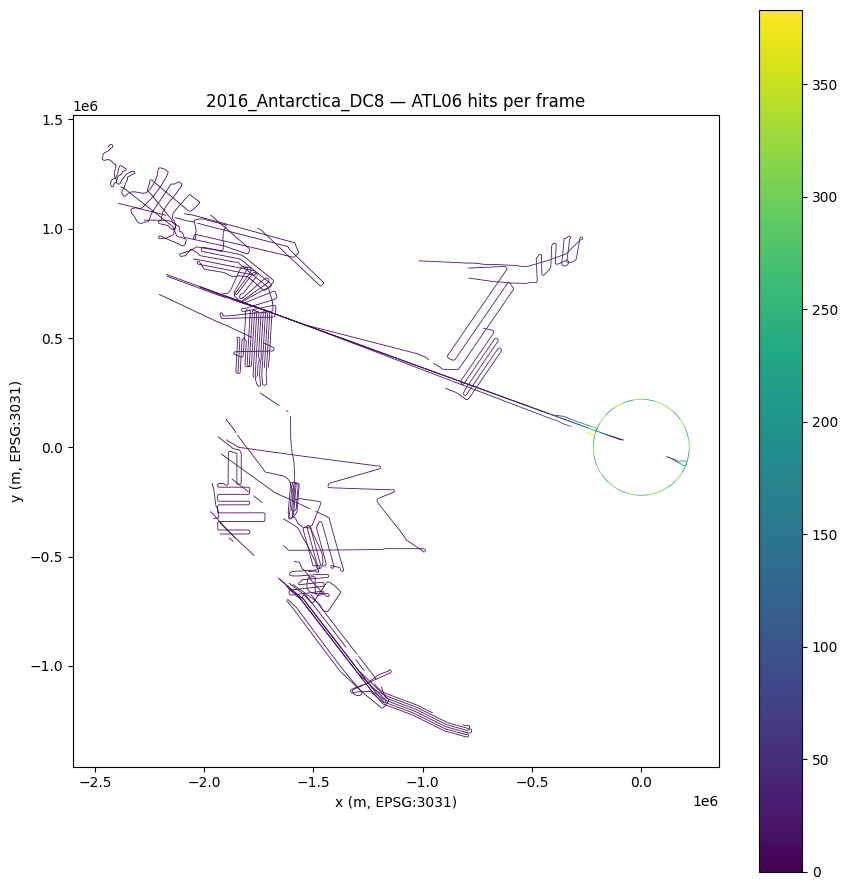

In [13]:
result_3031 = result.to_crs(CRS)
fig, ax = plt.subplots(1, 1, figsize=(9, 9))
result_3031.plot(
    column="n_granules",
    cmap="viridis",
    linewidth=0.6,
    legend=True,
    ax=ax,
)
ax.set_title(f"{frames['collection'].iloc[0]} — ATL06 hits per frame")
ax.set_xlabel("x (m, EPSG:3031)")
ax.set_ylabel("y (m, EPSG:3031)")
ax.set_aspect("equal")
plt.tight_layout()

## Follow-ups

Planned (see issue [#86](https://github.com/englacial/xopr/issues/86)):

1. **Read-along demo** — pick a frame with hits, open a matched ATL06 granule via h5coro or icepyx, clip to a buffer around the frame LineString, and co-plot ATL06 surface elevations against the frame's radar echogram / picked surface layer.
2. **Reverse direction** — given one ATL06 ground track, find every xOPR frame across all seasons that crosses it.
3. **Persistent local catalog** — mirror magg's on-disk JSON catalog so repeated notebook runs don't hit CMR.
4. **Unified prefix core** — share one prefix-matching implementation between `xopr.bedmap.morton_match` and `xopr.crossovers` once both workflows are stable.